In [1]:
# Implementation of a short straddle strategy selling ATM options expiry T = 3 months, no buy backs
# Daily PnL is calculated using capital gains of option premium 

'''
Sell ATM options on days when the portfolio doesn't already have open positions.
Rebalance the portfolio daily based on delta, either buying or short selling the underlying stock.
Calculate daily returns, taking into account the change in option premiums and the profit or loss from rebalancing the underlying stock.
Handle option expiration by checking if the options in the portfolio are expiring on the current day and calculating returns based on whether the options are exercised.
'''

import pandas as pd
import pandas_market_calendars as mcal
import numpy as np
import matplotlib.pyplot as plt
import math as math
from pandas import Timestamp
from equity import find_atm, reverse_option, get_hedge_count


In [2]:
# Load Data
AAPL_options_csv = 'AAPL_Options_22-23.csv'
AAPL_underlying_csv = 'AAPL_Underlying_22-23.csv'
AAPL_options = pd.read_csv(AAPL_options_csv, parse_dates = ["exdate", "date"])
AAPL_underlying = pd.read_csv(AAPL_underlying_csv, parse_dates = ["date"])
find_atm(AAPL_options_csv, AAPL_underlying_csv, pd.Timestamp(2022, 2, 28), 10, 90, 0.5)


[('AAPL 220520C155000', 'AAPL 220520P155000'),
 ('AAPL 220520P155000', 'AAPL 220520C155000'),
 ('AAPL 220520C160000', 'AAPL 220520P160000'),
 ('AAPL 220520P160000', 'AAPL 220520C160000'),
 ('AAPL 220520C165000', 'AAPL 220520P165000'),
 ('AAPL 220520P165000', 'AAPL 220520C165000'),
 ('AAPL 220520P130000', 'AAPL 220520C130000'),
 ('AAPL 220520C130000', 'AAPL 220520P130000'),
 ('AAPL 220520C185000', 'AAPL 220520P185000'),
 ('AAPL 220520P185000', 'AAPL 220520C185000')]

In [17]:
def get_hedge_count(options_df: pd.DataFrame, options_symbols: list[str], date: pd.Timestamp) -> int:
    total_delta = 0
    for symbol in options_symbols:
        option_at_given_time = options_df.loc[(options_df["symbol"] == symbol) & (options_df["date"] == date)]

        if not option_at_given_time.empty:
            delta = option_at_given_time["delta"].iloc[0]
            if not pd.isna(delta):
                total_delta += delta
        else:
            # Handle the case where the option_at_given_time DataFrame is empty
            print(f"No data for {symbol} on {date}")
            continue  # Skip to the next iteration if no data found

    return int(-1 * round(total_delta) * 100)

def backtest_short_straddle_with_premium_change(options_df, underlying_df, start_date, end_date):
    portfolio = {'options': [], 'underlying': 0, 'cash': 0}
    daily_returns = []
    previous_cash = 0 # Initialize previous day's cash balance
    nyse_calendar = mcal.get_calendar('NYSE')
    trading_days = nyse_calendar.schedule(start_date, end_date)
    trading_day_index = mcal.date_range(trading_days, frequency='1D')
    # Change all dates to timestamps, with time 00:00:00
    trading_day_index = [pd.Timestamp(date.date()) for date in trading_day_index]

    for current_date in trading_day_index:
        print(current_date)
        daily_unrealized_pnl = 0  # Initialize daily unrealized profit/loss from options
        
        # Process options expiring today
        options_to_remove = []
        for option in portfolio['options']:
            # Fetch the option data that is most current as of the current_date
            option_data_latest = options_df.loc[(options_df['symbol'] == option['symbol']) & (options_df['date'] <= current_date)].sort_values(by='date').iloc[-1]
            
            if option_data_latest['exdate'] == current_date:
                # Calculate and realize P&L from option expiration
                spot_price = underlying_df.loc[underlying_df['date'] == current_date, 'PRC'].item()
                pnl = max(option_data_latest['strike_price'] / 1000 - spot_price, 0) if 'P' in option_data_latest['symbol'] else max(spot_price - option_data_latest['strike_price'] / 1000, 0)
                pnl *= option_data_latest['contract_size']
                portfolio['cash'] += pnl - option['premium_received']
                options_to_remove.append(option)
            else:
                # Calculate unrealized P&L for non-expiring options using the most recent premium information
                current_premium = (option_data_latest['best_bid'] + option_data_latest['best_offer']) / 2
                premium_change = option['premium_received'] - current_premium * option_data_latest['contract_size']
                daily_unrealized_pnl += premium_change

        # Remove expired options
        for option in options_to_remove:
            portfolio['options'].remove(option)

        # Sell new ATM options if needed
        if not portfolio['options']:
            atm_options = find_atm(AAPL_options_csv, AAPL_underlying_csv, current_date, 10, 90, 0.5)
            for call_id, put_id in atm_options:
                call_data = options_df.loc[options_df['symbol'] == call_id].iloc[0]
                put_data = options_df.loc[options_df['symbol'] == put_id].iloc[0]
                call_premium = (call_data['best_bid'] + call_data['best_offer']) / 2 * call_data['contract_size']
                put_premium = (put_data['best_bid'] + put_data['best_offer']) / 2 * put_data['contract_size']
                portfolio['options'].append({'symbol': call_id, 'premium_received': call_premium})
                portfolio['options'].append({'symbol': put_id, 'premium_received': put_premium})
                portfolio['cash'] += call_premium + put_premium

        # Daily rebalance based on delta
        portfolio_option_symbols = [option['symbol'] for option in portfolio['options']]
            
        # hedge_count = get_hedge_count(options_df, portfolio_option_symbols, current_date)
        # underlying_df.head()
        # rebalance_cost = (hedge_count - portfolio['underlying']) * underlying_df.loc[underlying_df['date'] == current_date, 'PRC'].item()
        # portfolio['underlying'] = hedge_count
        # portfolio['cash'] -= rebalance_cost

        # Adjusted rebalancing code snippet
        hedge_adjustment = get_hedge_count(options_df, portfolio_option_symbols, current_date)
        current_price = underlying_df.loc[underlying_df['date'] == current_date, 'PRC'].item()
        rebalance_cost = hedge_adjustment * current_price
        portfolio['underlying'] += hedge_adjustment  # Adjust the current holding based on the hedge count
        portfolio['cash'] -= rebalance_cost  # Adjust the cash position based on the cost to rebalance

        # Add daily unrealized P&L from options to daily returns
        # Calculate and include real cash changes in daily P&L
        cash_change = portfolio['cash'] - previous_cash
        daily_pnl = daily_unrealized_pnl + cash_change  # Update to include cash change
        daily_returns.append(daily_pnl)

        previous_cash = portfolio['cash']

    return pd.Series(daily_returns, index=trading_day_index)

# Execute the backtest
daily_returns = backtest_short_straddle_with_premium_change(AAPL_options, AAPL_underlying, AAPL_options['date'].min(), AAPL_options['date'].max())

2022-02-28 00:00:00
2022-03-01 00:00:00
2022-03-02 00:00:00
2022-03-03 00:00:00
2022-03-04 00:00:00
2022-03-07 00:00:00
2022-03-08 00:00:00
2022-03-09 00:00:00
2022-03-10 00:00:00
2022-03-11 00:00:00
2022-03-14 00:00:00
2022-03-15 00:00:00
2022-03-16 00:00:00
2022-03-17 00:00:00
2022-03-18 00:00:00
2022-03-21 00:00:00
2022-03-22 00:00:00
2022-03-23 00:00:00
2022-03-24 00:00:00
2022-03-25 00:00:00
2022-03-28 00:00:00
2022-03-29 00:00:00
2022-03-30 00:00:00
2022-03-31 00:00:00
2022-04-01 00:00:00
2022-04-04 00:00:00
2022-04-05 00:00:00
2022-04-06 00:00:00
2022-04-07 00:00:00
2022-04-08 00:00:00
2022-04-11 00:00:00
2022-04-12 00:00:00
2022-04-13 00:00:00
2022-04-14 00:00:00
2022-04-18 00:00:00
2022-04-19 00:00:00
2022-04-20 00:00:00
2022-04-21 00:00:00
2022-04-22 00:00:00
2022-04-25 00:00:00
2022-04-26 00:00:00
2022-04-27 00:00:00
2022-04-28 00:00:00
2022-04-29 00:00:00
2022-05-02 00:00:00
2022-05-03 00:00:00
2022-05-04 00:00:00
2022-05-05 00:00:00
2022-05-06 00:00:00
2022-05-09 00:00:00


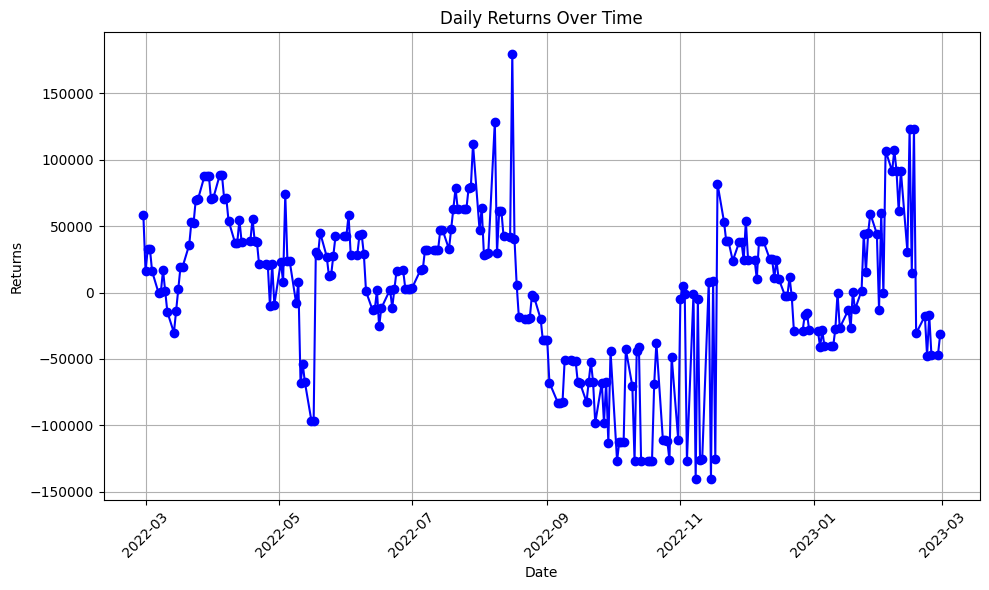

328846.04800000275
2022-02-28    58193.000
2022-03-01    15874.000
2022-03-02    32977.000
2022-03-03    32965.000
2022-03-04    15943.000
                ...    
2023-02-22   -47510.000
2023-02-23   -17151.998
2023-02-24   -47096.004
2023-02-27   -46772.000
2023-02-28   -31560.000
Length: 252, dtype: float64


In [18]:
# Assuming daily_returns is a pandas Series with a datetime index
plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(daily_returns.index, daily_returns.values, marker='o', linestyle='-', color='b')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.show()  # Display the plot

total_returns = daily_returns.sum()
print(total_returns)
print(daily_returns)

In [19]:
def get_hedge_count(options_df: pd.DataFrame, options_symbols: list[str], date: pd.Timestamp) -> int:
    total_delta = 0
    for symbol in options_symbols:
        option_at_given_time = options_df.loc[(options_df["symbol"] == symbol) & (options_df["date"] == date)]

        if not option_at_given_time.empty:
            delta = option_at_given_time["delta"].iloc[0]
            if not pd.isna(delta):
                total_delta += delta
        else:
            # Handle the case where the option_at_given_time DataFrame is empty
            print(f"No data for {symbol} on {date}")
            continue  # Skip to the next iteration if no data found

    return int(-1 * round(total_delta) * 100)

def backtest_short_straddle_with_premium_change(options_df, underlying_df, start_date, end_date):
    portfolio = {'options': [], 'underlying': 0, 'cash': 0}
    daily_returns = []
    previous_cash = 0 # Initialize previous day's cash balance
    nyse_calendar = mcal.get_calendar('NYSE')
    trading_days = nyse_calendar.schedule(start_date, end_date)
    trading_day_index = mcal.date_range(trading_days, frequency='1D')
    # Change all dates to timestamps, with time 00:00:00
    trading_day_index = [pd.Timestamp(date.date()) for date in trading_day_index]

    for current_date in trading_day_index:
        print(current_date)
        daily_unrealized_pnl = 0  # Initialize daily unrealized profit/loss from options
        
        # Process options expiring today
        options_to_remove = []
        for option in portfolio['options']:
            # Fetch the option data that is most current as of the current_date
            option_data_latest = options_df.loc[(options_df['symbol'] == option['symbol']) & (options_df['date'] <= current_date)].sort_values(by='date').iloc[-1]
            
            if option_data_latest['exdate'] == current_date:
                # Calculate and realize P&L from option expiration
                spot_price = underlying_df.loc[underlying_df['date'] == current_date, 'PRC'].item()
                pnl = max(option_data_latest['strike_price'] / 1000 - spot_price, 0) if 'P' in option_data_latest['symbol'] else max(spot_price - option_data_latest['strike_price'] / 1000, 0)
                pnl *= option_data_latest['contract_size']
                portfolio['cash'] += pnl - option['premium_received']
                options_to_remove.append(option)
            else:
                # Calculate unrealized P&L for non-expiring options using the most recent premium information
                current_premium = (option_data_latest['best_bid'] + option_data_latest['best_offer']) / 2
                premium_change = option['premium_received'] - current_premium * option_data_latest['contract_size']
                daily_unrealized_pnl += premium_change

        # Remove expired options
        for option in options_to_remove:
            portfolio['options'].remove(option)

        # Sell new ATM options if needed
        if not portfolio['options']:
            atm_options = find_atm(AAPL_options_csv, AAPL_underlying_csv, current_date, 10, 90, 0.5)
            for call_id, put_id in atm_options:
                call_data = options_df.loc[options_df['symbol'] == call_id].iloc[0]
                put_data = options_df.loc[options_df['symbol'] == put_id].iloc[0]
                call_premium = (call_data['best_bid'] + call_data['best_offer']) / 2 * call_data['contract_size']
                put_premium = (put_data['best_bid'] + put_data['best_offer']) / 2 * put_data['contract_size']
                portfolio['options'].append({'symbol': call_id, 'premium_received': call_premium})
                portfolio['options'].append({'symbol': put_id, 'premium_received': put_premium})
                portfolio['cash'] += call_premium + put_premium

        # Daily rebalance based on delta
        portfolio_option_symbols = [option['symbol'] for option in portfolio['options']]
            
        # hedge_count = get_hedge_count(options_df, portfolio_option_symbols, current_date)
        # underlying_df.head()
        # rebalance_cost = (hedge_count - portfolio['underlying']) * underlying_df.loc[underlying_df['date'] == current_date, 'PRC'].item()
        # portfolio['underlying'] = hedge_count
        # portfolio['cash'] -= rebalance_cost

        # # Adjusted rebalancing code snippet
        # hedge_adjustment = get_hedge_count(options_df, portfolio_option_symbols, current_date)
        # current_price = underlying_df.loc[underlying_df['date'] == current_date, 'PRC'].item()
        # rebalance_cost = hedge_adjustment * current_price
        # portfolio['underlying'] += hedge_adjustment  # Adjust the current holding based on the hedge count
        # portfolio['cash'] -= rebalance_cost  # Adjust the cash position based on the cost to rebalance

        # Add daily unrealized P&L from options to daily returns
        # Calculate and include real cash changes in daily P&L
        cash_change = portfolio['cash'] - previous_cash
        daily_pnl = daily_unrealized_pnl + cash_change  # Update to include cash change
        daily_returns.append(daily_pnl)

        previous_cash = portfolio['cash']

    return pd.Series(daily_returns, index=trading_day_index)

# Execute the backtest
daily_returns_no_rebalancing = backtest_short_straddle_with_premium_change(AAPL_options, AAPL_underlying, AAPL_options['date'].min(), AAPL_options['date'].max())

2022-02-28 00:00:00
2022-03-01 00:00:00
2022-03-02 00:00:00
2022-03-03 00:00:00
2022-03-04 00:00:00
2022-03-07 00:00:00
2022-03-08 00:00:00
2022-03-09 00:00:00
2022-03-10 00:00:00
2022-03-11 00:00:00
2022-03-14 00:00:00
2022-03-15 00:00:00
2022-03-16 00:00:00
2022-03-17 00:00:00
2022-03-18 00:00:00
2022-03-21 00:00:00
2022-03-22 00:00:00
2022-03-23 00:00:00
2022-03-24 00:00:00
2022-03-25 00:00:00
2022-03-28 00:00:00
2022-03-29 00:00:00
2022-03-30 00:00:00
2022-03-31 00:00:00
2022-04-01 00:00:00
2022-04-04 00:00:00
2022-04-05 00:00:00
2022-04-06 00:00:00
2022-04-07 00:00:00
2022-04-08 00:00:00
2022-04-11 00:00:00
2022-04-12 00:00:00
2022-04-13 00:00:00
2022-04-14 00:00:00
2022-04-18 00:00:00
2022-04-19 00:00:00
2022-04-20 00:00:00
2022-04-21 00:00:00
2022-04-22 00:00:00
2022-04-25 00:00:00
2022-04-26 00:00:00
2022-04-27 00:00:00
2022-04-28 00:00:00
2022-04-29 00:00:00
2022-05-02 00:00:00
2022-05-03 00:00:00
2022-05-04 00:00:00
2022-05-05 00:00:00
2022-05-06 00:00:00
2022-05-09 00:00:00


In [20]:
print(daily_returns)
print(daily_returns_no_rebalancing)
print(daily_returns_no_rebalancing.sum())

2022-02-28    58193.000
2022-03-01    15874.000
2022-03-02    32977.000
2022-03-03    32965.000
2022-03-04    15943.000
                ...    
2023-02-22   -47510.000
2023-02-23   -17151.998
2023-02-24   -47096.004
2023-02-27   -46772.000
2023-02-28   -31560.000
Length: 252, dtype: float64
2022-02-28    25169.0
2022-03-01     -446.0
2022-03-02     -335.0
2022-03-03     -281.0
2022-03-04     -374.0
               ...   
2023-02-22    12054.0
2023-02-23    12728.0
2023-02-24    11588.0
2023-02-27    12396.0
2023-02-28    12663.0
Length: 252, dtype: float64
2442555.02
